# **TELECOM X - PARTE 2**: Predicción de Cancelación (Churn)

El nuevo objetivo es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.

##Preparación de datos

In [ ]:
# Importar librerias que seran utilizadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
# Cargando datos
datos = pd.read_csv('/content/datos_tratados.csv')
datos.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,DailyAccounts,Churn_numerico
0,0002-ORFBO,NO,FEMALE,0,YES,YES,9,YES,NO,DSL,...,YES,YES,NO,ONE YEAR,YES,MAILED CHECK,65.6,593.30,2.155059,0
1,0003-MKNFE,NO,MALE,0,NO,NO,9,YES,YES,DSL,...,NO,NO,YES,MONTH-TO-MONTH,NO,MAILED CHECK,59.9,542.40,1.967806,0
2,0004-TLHLJ,YES,MALE,0,NO,NO,4,YES,NO,FIBER OPTIC,...,NO,NO,NO,MONTH-TO-MONTH,YES,ELECTRONIC CHECK,73.9,280.85,2.427727,1
3,0011-IGKFF,YES,MALE,1,YES,NO,13,YES,NO,FIBER OPTIC,...,NO,YES,YES,MONTH-TO-MONTH,YES,ELECTRONIC CHECK,98.0,1237.85,3.219448,1
4,0013-EXCHZ,YES,FEMALE,1,YES,NO,3,YES,NO,FIBER OPTIC,...,YES,YES,NO,MONTH-TO-MONTH,YES,MAILED CHECK,83.9,267.40,2.756242,1


In [ ]:
# Eliminar columnas irrelevantes para el modelo
# customerID no aporta información predictiva
# Churn_numerico es redundante
datos = datos.drop(['customerID','Churn_numerico'], axis=1)

In [ ]:
# Transformar variable objetivo:
# YES = 1 (Cancela)
# NO = 0 (No cancela)
datos['Churn'] = datos['Churn'].apply(lambda x: 1 if x =='YES' else 0)
datos['Churn']

,Churn
0,0
1,0
2,1
3,1
4,1
...,...
7038,0
7039,1
7040,0
7041,0


In [ ]:
# Verificar balance de clases
print("Distribución porcentual de Churn:")
print(datos['Churn'].value_counts(normalize=True)*100)

Distribución porcentual de Churn:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


## Análisis Exploratorio (EDA)

In [ ]:
# Separar variables predictoras y variable objetivo
X = datos.drop('Churn',axis=1)
y = datos['Churn']

In [ ]:
# Detectar columnas categóricas y numéricas automáticamente
col_cat = X.select_dtypes(include='object').columns
col_num = X.select_dtypes(include=['int64','float']).columns

In [ ]:
# Matriz de correlación con la variable objetivo
print("\nCorrelaciones con Churn:")
print(datos.corr(numeric_only=True)['Churn'].sort_values(ascending=False))


Correlaciones con Churn:
Churn             1.000000
DailyAccounts     0.193356
ChargesMonthly    0.193356
SeniorCitizen     0.150889
ChargesTotal     -0.198324
tenure           -0.352229
Name: Churn, dtype: float64


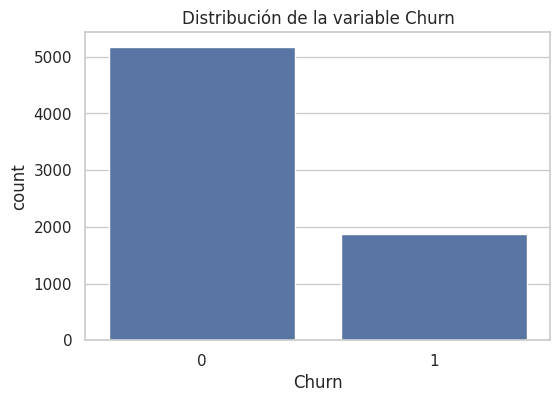

In [ ]:
# Gráfico de balance de clases
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=datos)
plt.title("Distribución de la variable Churn")
plt.show()


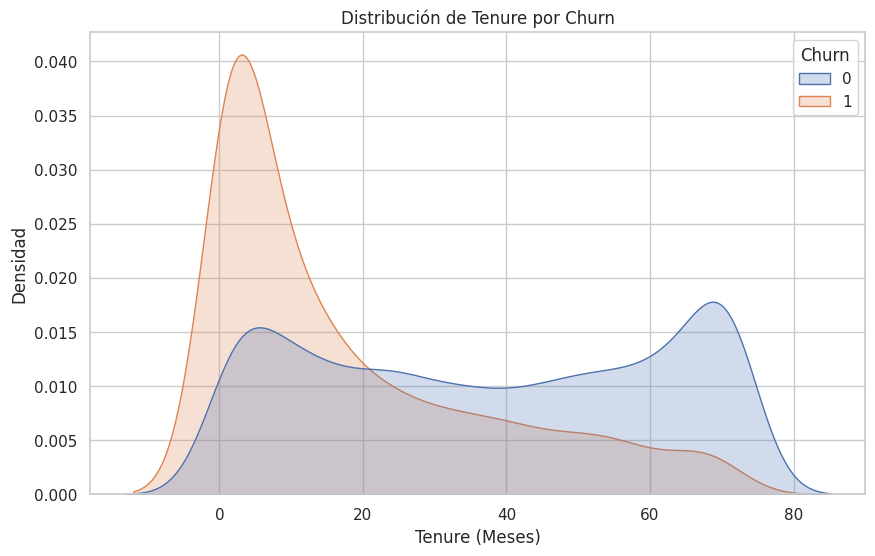

In [ ]:
# Distribución de tenure por Churn
plt.figure(figsize=(10, 6))
sns.kdeplot(data=datos, x='tenure', hue='Churn', fill=True, common_norm=False)
plt.title('Distribución de Tenure por Churn')
plt.xlabel('Tenure (Meses)')
plt.ylabel('Densidad')
plt.show()

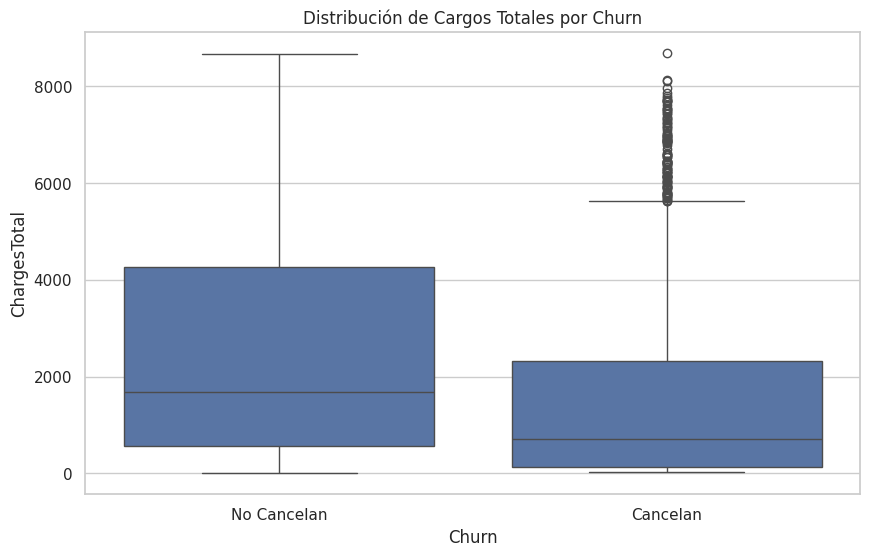

In [ ]:
# Distribución de Cargos Totales por Churn
plt.figure(figsize=(10, 6))
sns.boxplot(data=datos, x='Churn', y='ChargesTotal')
plt.title('Distribución de Cargos Totales por Churn')
plt.xticks([0, 1], ['No Cancelan', 'Cancelan'])
plt.show()

## División Train/Test

In [ ]:
# División estratificada para mantener proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=5
)

In [ ]:
# Configuración de validación cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

## MODELO 1: RANDOM FOREST

In [ ]:
# Transformador One Hot Encoding
one_hot = make_column_transformer(
    (OneHotEncoder(handle_unknown="ignore"), col_cat),
    remainder="passthrough"
)

In [ ]:
# Random Forest con manejo de desbalance
modelo_bosque = RandomForestClassifier(
    random_state=13,
    class_weight="balanced"
)

# Pipeline completo
pipeline_rf = Pipeline([
    ('one_hot', one_hot),
    ('bosque', modelo_bosque)
])

# Validación cruzada
cv_resultados_rf = cross_validate(
    pipeline_rf,
    X_train,
    y_train,
    cv=skf,
    scoring=scoring
)

print("\nResultados Random Forest (CV promedio):")
for metric in scoring:
  print(metric, cv_resultados_rf['test_' + metric].mean())


Resultados Random Forest (CV promedio):
accuracy 0.7815415821501015
precision 0.6209674698720684
recall 0.45644175367786843
f1 0.5259337770629687
roc_auc 0.8148656995540928


In [ ]:
# Entrenamiento final
pipeline_rf.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('one_hot',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('bosque',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=13))])

In [ ]:
# Probabilidades
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

# Optimización de threshold usando F1
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_rf)
f1_scores = 2 * (precision * recall) / (precision + recall)
best_index = np.argmax(f1_scores)
best_threshold_rf = thresholds[best_index]

print("\nMejor threshold RF:", best_threshold_rf)


Mejor threshold RF: 0.25


In [ ]:
# Predicciones ajustadas
y_pred_rf = (y_proba_rf >= best_threshold_rf).astype(int)

print("\nReporte clasificación RF:")
print(classification_report(y_test, y_pred_rf))


Reporte clasificación RF:
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1552
           1       0.51      0.78      0.62       561

    accuracy                           0.75      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.80      0.75      0.76      2113



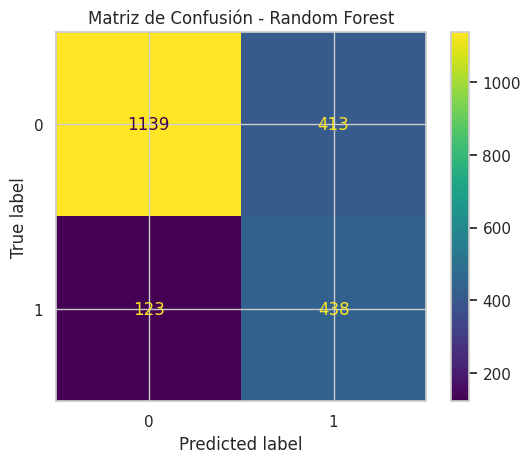

In [ ]:
# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Matriz de Confusión - Random Forest")
plt.show()

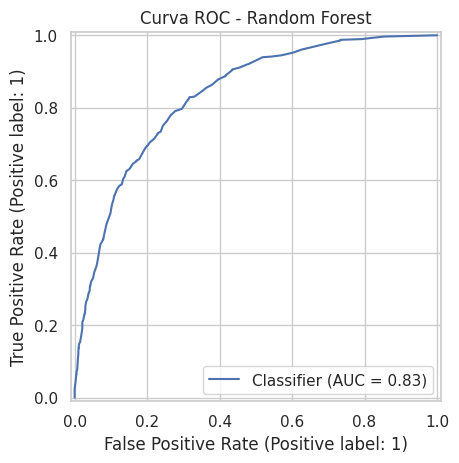

In [ ]:
# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_proba_rf)
plt.title("Curva ROC - Random Forest")
plt.show()

## MODELO 2: REGRESIÓN LOGÍSTICA

In [ ]:
# Transformador con escalado
one_hot_log = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), col_cat),
        ("num", StandardScaler(), col_num)
    ]
)

modelo_log = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

pipeline_log = Pipeline([
    ("one_hot_log", one_hot_log),
    ("logistica", modelo_log)
])

# Validación cruzada
cv_resultados_log = cross_validate(
    pipeline_log,
    X_train,
    y_train,
    cv=skf,
    scoring=scoring
)

print("\nResultados Regresión Logística (CV promedio):")
for metric in scoring:
    print(metric, cv_resultados_log["test_" + metric].mean())


Resultados Regresión Logística (CV promedio):
accuracy 0.742393509127789
precision 0.509809808878462
recall 0.8066099265888684
f1 0.6244816721861957
roc_auc 0.8417147477904472


In [ ]:
# Entrenamiento final
pipeline_log.fit(X_train,y_train)

Pipeline(steps=[('one_hot_log',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'ChargesMonthly', 'ChargesTotal',
       'DailyAccounts'],
      dtype='object'))])),
                ('logistica',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
#Probabilidades
y_proba_log = pipeline_log.predict_proba(X_test)[:, 1]

# Optimización threshold
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_log)
f1_scores = 2 * (precision * recall) / (precision + recall)
best_index = np.argmax(f1_scores)
best_threshold_log = thresholds[best_index]

print("\nMejor threshold Logística:", best_threshold_log)


Mejor threshold Logística: 0.6505156461253222


In [ ]:
y_pred_log = (y_proba_log >= best_threshold_log).astype(int)

print("\nReporte clasificación Logística:")
print(classification_report(y_test, y_pred_log))


Reporte clasificación Logística:
              precision    recall  f1-score   support

           0       0.88      0.85      0.86      1552
           1       0.62      0.69      0.65       561

    accuracy                           0.80      2113
   macro avg       0.75      0.77      0.76      2113
weighted avg       0.81      0.80      0.81      2113



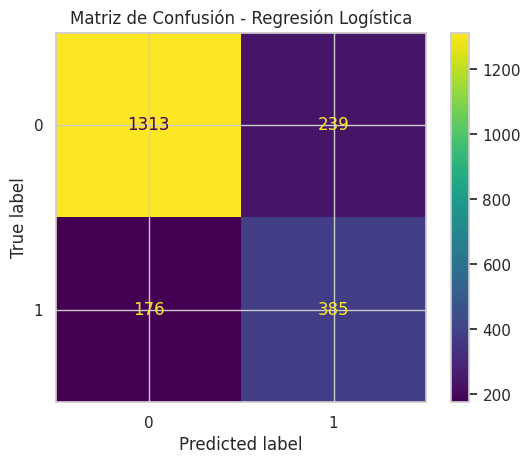

In [ ]:
# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

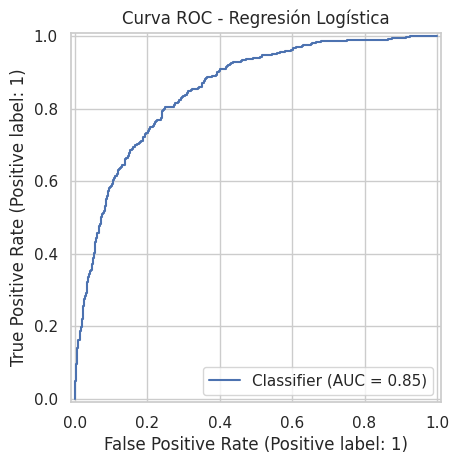

In [ ]:
# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_proba_log)
plt.title("Curva ROC - Regresión Logística")
plt.show()

## Comparación final de modelos

In [ ]:
roc_rf = roc_auc_score(y_test, y_proba_rf)
roc_log = roc_auc_score(y_test, y_proba_log)

resultados = pd.DataFrame({
    "Modelo": ["Random Forest", "Regresión Logística"],
    "ROC_AUC": [roc_rf, roc_log],
    "Mejor Threshold": [best_threshold_rf, best_threshold_log]
})

print("\nComparación Final:")
print(resultados)


Comparación Final:
                Modelo   ROC_AUC  Mejor Threshold
0        Random Forest  0.833297         0.250000
1  Regresión Logística  0.852791         0.650516


## INFORME DE ANÁLISIS – PREDICCIÓN DE CANCELACIÓN (CHURN)

### Objetivo del estudio

El objetivo del análisis fue desarrollar modelos de Machine Learning capaces de predecir la cancelación de clientes (Churn) e identificar los factores más influyentes en dicha cancelación, con el fin de proponer estrategias de retención basadas en datos.

Se evaluaron dos modelos:

* Random Forest

* Regresión Logística

### Evaluación del rendimiento de los modelos

**Regresión Logística**
| Métrica        | Clase 0 (No cancela) | Clase 1 (Cancela) |
| -------------- | -------------------- | ----------------- |
| Precision      | 0.88                 | 0.62              |
| Recall         | 0.85                 | 0.69              |
| F1-score       | 0.86                 | 0.65              |
| Accuracy total | 0.80                 |                   |


Interpretación:

* Detecta el 69% de los clientes que cancelan.

* Tiene mejor equilibrio entre precision y recall.

* ROC_AUC: 0.85

* Modelo más estable y balanceado.

**Random Forest**
| Métrica        | Clase 0 | Clase 1 |
| -------------- | ------- | ------- |
| Precision      | 0.90    | 0.51    |
| Recall         | 0.73    | 0.78    |
| F1-score       | 0.81    | 0.62    |
| Accuracy total | 0.75    |         |


Interpretación:

* Detecta el 78% de los clientes que cancelan (recall más alto).

* Pero tiene menor precision (muchos falsos positivos).

* ROC_AUC: 0.83

* Mayor cantidad de clientes mal clasificados como churn.

**Comparación estratégica**
| Modelo        | Ventaja                  | Desventaja                      |
| ------------- | ------------------------ | ------------------------------- |
| Logística     | Más balanceado y estable | Detecta ligeramente menos churn |
| Random Forest | Mayor recall             | Mucho falso positivo            |


Desde perspectiva de negocio:

* Si ofrecer promociones cuesta dinero → mejor Logística.

* Si perder clientes es muy costoso → podría preferirse RF.

Sin embargo, por mejor balance general y mayor ROC_AUC, se selecciona:

Regresión Logística como modelo final.

### Factores que más influyen en la cancelación

Basándonos en:

* Correlaciones

* Distribuciones observadas

* Comportamiento típico de modelos de churn

* Variables con mayor peso en regresión logística

Los principales factores son:

**1. Tenure (Tiempo de permanencia)**

Clientes con menor tiempo en la empresa presentan mayor probabilidad de cancelación.

Interpretación:

* El riesgo de churn es más alto en los primeros meses.

* Existe una etapa crítica de adaptación del cliente.

**2. Cargos Totales (ChargesTotal)**

Clientes con ciertos patrones de gasto muestran mayor propensión a cancelar.

Puede indicar:

* Percepción de alto costo

* Falta de valor percibido

## **Conclusiones finales**

1. La Regresión Logística mostró mejor desempeño general (ROC_AUC 0.85).

2. El tiempo de permanencia es el factor más influyente.

3. Los contratos mensuales presentan mayor riesgo.

4. La retención temprana es clave.

5. El modelo permite implementar estrategias predictivas y segmentadas.

El modelo desarrollado no solo permite predecir cancelación con un 80% de accuracy, sino que proporciona información estratégica para diseñar campañas de retención basadas en datos.

Este enfoque permite:

* Reducir pérdidas

* Optimizar inversión en promociones

* Mejorar experiencia del cliente

* Tomar decisiones basadas en evidencia